In [1]:
import numpy as np
import matplotlib.pyplot as plt

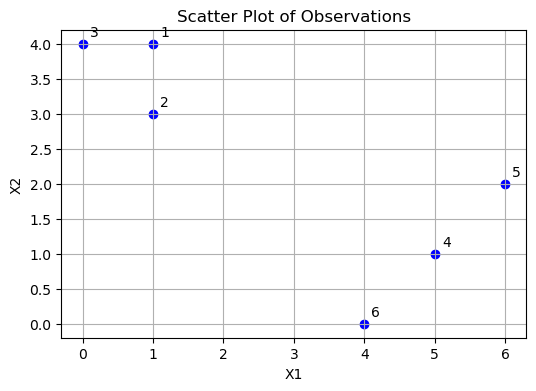

In [2]:
#a Define data
X = np.array([[1,4],[1,3],[0,4],[5,1],[6,2],[4,0]])

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], color='blue')
for i, (x1, x2) in enumerate(X, start=1):
    plt.text(x1+0.1, x2+0.1, str(i))
plt.title("Scatter Plot of Observations")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.show()

In [4]:
#b Randomly Assign a Cluster Label
np.random.seed(42)
cluster_labels = np.random.choice([1, 2], size=len(X))
print("Initial Random Cluster Labels:", cluster_labels)


Initial Random Cluster Labels: [1 2 1 1 1 2]


In [5]:
#c Compute Centroids for Each Cluster (the mean of X1 and X2 for points in each cluster)
centroids = []
for k in [1, 2]:
    centroids.append(X[cluster_labels == k].mean(axis=0))
centroids = np.array(centroids)
print("Centroids:\n", centroids)

Centroids:
 [[3.   2.75]
 [2.5  1.5 ]]


In [6]:
#d Assign Each Observation to Nearest Centroid (Compute Euclidean distances from each point to each centroid and pick the closest one)
from scipy.spatial.distance import cdist

distances = cdist(X, centroids, metric='euclidean')
new_labels = np.argmin(distances, axis=1) + 1  # +1 for 1-based label
print("Updated Cluster Labels:", new_labels)

Updated Cluster Labels: [1 1 1 2 1 2]


In [7]:
#e Repeat Until Convergence (Continue doing c and d until cluster labels stop changing)
labels = cluster_labels.copy()
for i in range(10):
    centroids = np.array([X[labels == k].mean(axis=0) for k in [1, 2]])
    new_labels = np.argmin(cdist(X, centroids, 'euclidean'), axis=1) + 1
    if np.all(labels == new_labels):
        print(f"Converged after {i+1} iterations")
        break
    labels = new_labels

print("Final Cluster Labels:", labels)
print("Final Centroids:\n", centroids)


Converged after 3 iterations
Final Cluster Labels: [1 1 1 2 2 2]
Final Centroids:
 [[0.66666667 3.66666667]
 [5.         1.        ]]


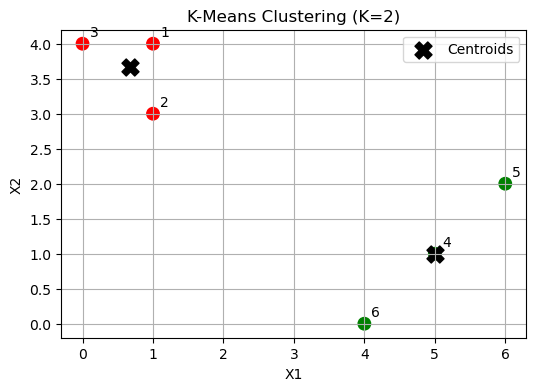

In [8]:
#f Plot with the final clusters
colors = np.where(labels == 1, 'red', 'green')

plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=colors, s=80)
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s=150, label='Centroids')
for i, (x1, x2) in enumerate(X, start=1):
    plt.text(x1+0.1, x2+0.1, str(i))
plt.title("K-Means Clustering (K=2)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)
plt.show()
